In [44]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import minimize

from scipy.interpolate import RegularGridInterpolator
from matplotlib.widgets import Slider

In [45]:
# =========================
# Global simulation config 
# =========================
Vdc     = 48.0    # V
rpm_max = 6000    # rpm  (slider upper limit & LUT coverage)
rpm_min = 0     # rpm  (slider lower limit)

p_ = {
    "pole_pairs": 4,
    "Ld":         0.004,   # H
    "Lq":         0.008,   # H
    "psi_f":      0.01,    # Wb
    "Imax":       20.0,    # A
    "alpha":      1/3,     # voltage utilization factor
}

# Derived: flux grid bounds (computed once here, reused in LUT build & slider)
lam_lower = (p_["alpha"] * Vdc) / (p_["pole_pairs"] * rpm_max * 2 * np.pi / 60)
lam_upper = np.hypot(
    p_["psi_f"] + p_["Ld"] * p_["Imax"],
    p_["Lq"]   * p_["Imax"]
) * 1.05


In [46]:
# =========================
# Shared motor model (no Rs, no saturation, no losses)
# =========================
def Te(id_, iq, p_):
    # IPMSM torque (magnet torque + reluctance torque)
    return 1.5 * p_["pole_pairs"] * (p_["psi_f"] * iq + (p_["Ld"] - p_["Lq"]) * id_ * iq)


def lam_d(id_, p_):
    return p_["psi_f"] + p_["Ld"] * id_


def lam_q(iq, p_):
    return p_["Lq"] * iq


def lam_mag(id_, iq, p_):
    # |lambda| = sqrt(lambda_d^2 + lambda_q^2)
    return float(np.hypot(lam_d(id_, p_), lam_q(iq, p_)))

In [47]:
# =========================
# Part I: (rpm, Vdc) -> lambda_max (flux magnitude limit)
# Assumption: Rs=0, lossless -> |v| = omega_e * |lambda|
# => lambda_max = Vmax / omega_e
# =========================
def part1_lambda_max_ff(rpm, Vdc, p_):
    omega_mech = rpm * 2 * np.pi / 60.0          # mechanical speed [rad/s]
    omega_e = p_["pole_pairs"] * omega_mech       # electrical speed [rad/s]
    Vmax = p_["alpha"] * Vdc                      # effective voltage limit (alpha: modulation headroom, e.g. 1/sqrt(3) for SVPWM)
    # At Rs=0: |v| = omega_e * |lambda|  =>  |lambda_max| = Vmax / omega_e
    return float(Vmax / max(abs(omega_e), 1e-9))  # clamp denominator to avoid division by zero at rpm=0


# =========================
# Part III OFFLINE: build LUT for Tmax(lambda_max)
# maximize Te s.t. current limit and flux limit
# id <= 0, iq >= 0 (motoring + field-weakening quadrant)
# =========================
def solve_Tmax_for_lammax(lam_max, p_):
    Imax = p_["Imax"]
    bounds = [(-Imax, 0.0), (0.0, Imax)]  # id <= 0 (demagnetizing), iq >= 0 (torque-producing)

    def obj(x):
        return -Te(x[0], x[1], p_)        # negate because scipy minimizes

    cons = [
        # (C1) Stay inside current limit circle: id^2 + iq^2 <= Imax^2
        {"type": "ineq", "fun": lambda x: Imax**2 - (x[0] ** 2 + x[1] ** 2)},
        # (C2) Stay inside flux limit circle: |lambda(id,iq)| <= lambda_max
        #      This is the voltage-derived constraint (field-weakening boundary)
        {"type": "ineq", "fun": lambda x: lam_max - lam_mag(x[0], x[1], p_)},
    ]

    # Multiple initial guesses to avoid local minima in non-convex IPMSM landscape
    inits = []
    inits.append(np.array([0.0, min(Imax, 5.0)]))   # near no-load
    for frac in [0.2, 0.5, 0.8, 1.0]:
        iq0 = frac * Imax
        id0 = -np.sqrt(max(Imax**2 - iq0**2, 0.0))  # on the current-limit circle
        inits.append(np.array([id0, iq0]))
    inits.append(np.array([-0.5 * Imax, 0.5 * Imax]))

    best_T = -np.inf
    best_x = (np.nan, np.nan)

    for x0 in inits:
        res = minimize(
            obj,
            x0,
            method="SLSQP",       # Sequential Least SQuares Programming — handles nonlinear constraints
            bounds=bounds,
            constraints=cons,
            options={"maxiter": 800, "ftol": 1e-12, "disp": False},
        )
        if not res.success:
            continue

        id_, iq = res.x
        # Post-check: reject solutions that violate constraints beyond tolerance
        if (id_**2 + iq**2) > Imax**2 + 1e-6:
            continue
        if lam_mag(id_, iq, p_) > lam_max + 1e-6:
            continue

        val = Te(id_, iq, p_)
        if val > best_T:           # keep the best feasible solution across all inits
            best_T = float(val)
            best_x = (float(id_), float(iq))

    if not np.isfinite(best_T):
        return np.nan, (np.nan, np.nan)   # no feasible solution found
    return best_T, best_x


def build_part3_LUT(lam_max_grid, p_):
    """
    Sweeps over a grid of lambda_max values and solves for
    the maximum achievable torque at each flux limit.
    Returns:
        Tmax_LUT    : array of max torque [Nm] for each lambda_max
        Id_at_Tmax  : optimal id [A] at each operating point
        Iq_at_Tmax  : optimal iq [A] at each operating point
    """
    Tmax_LUT   = np.full_like(lam_max_grid, np.nan, dtype=float)
    Id_at_Tmax = np.full_like(lam_max_grid, np.nan, dtype=float)
    Iq_at_Tmax = np.full_like(lam_max_grid, np.nan, dtype=float)

    print("Building Part III LUT: Tmax(lambda_max) ...")
    for k, lm in enumerate(lam_max_grid):
        Tmax, (id_opt, iq_opt) = solve_Tmax_for_lammax(float(lm), p_)
        Tmax_LUT[k]   = Tmax
        Id_at_Tmax[k] = id_opt
        Iq_at_Tmax[k] = iq_opt
    print("Done.")
    return Tmax_LUT, Id_at_Tmax, Iq_at_Tmax



In [48]:

# INPUT:  lam_max_grid  — sweep of flux-limit values [Wb]
#                         (represents different speeds: high rpm → small lam_max)
# OUTPUT: Tmax_LUT      — max achievable torque [Nm] at each flux limit
#         Id/Iq_at_Tmax — optimal (id*, iq*) current at each operating point
#                         (this is the MTPV trajectory in field-weakening)

# --- lam_max_grid: auto-compute from motor parameters ---

# Lower bound: λ at maximum rpm (where voltage budget is tightest)
lam_lower = (p_["alpha"] * Vdc) / (p_["pole_pairs"] * rpm_max * 2 * np.pi / 60)

# Upper bound: λ when all current is applied at low speed (no voltage constraint)
# |λ| = sqrt((psi_f + Ld*Imax)^2 + (Lq*Imax)^2)
lam_upper = np.hypot(
    p_["psi_f"] + p_["Ld"] * p_["Imax"],   # d-axis flux (PM + Ld*id)
    p_["Lq"]   * p_["Imax"]               # q-axis flux
) * 1.05  # 5% headroom

lam_max_grid = np.linspace(lam_lower, lam_upper, 80)

Tmax_LUT, Id_at_Tmax, Iq_at_Tmax = build_part3_LUT(lam_max_grid, p_)


# --- DataFrame 출력 ---
df = pd.DataFrame({
    "lam_max [Wb]": lam_max_grid,
    "Tmax [Nm]": Tmax_LUT,
    "Id* [A]": Id_at_Tmax,
    "Iq* [A]": Iq_at_Tmax,
})
print(df.to_string(index=False))


Building Part III LUT: Tmax(lambda_max) ...
Done.
 lam_max [Wb]  Tmax [Nm]    Id* [A]   Iq* [A]
     0.006366   0.099849  -2.931968  0.765904
     0.008726   0.141345  -3.235377  1.026848
     0.011085   0.186203  -3.574292  1.277259
     0.013444   0.234696  -3.935303  1.519590
     0.015804   0.286993  -4.310601  1.755796
     0.018163   0.343197  -4.695521  1.987329
     0.020522   0.403379  -5.087167  2.215246
     0.022882   0.467586  -5.483674  2.440322
     0.025241   0.535851  -5.883794  2.663130
     0.027600   0.608199  -6.286666  2.884102
     0.029960   0.684648  -6.691681  3.103569
     0.032319   0.765212  -7.098388  3.321788
     0.034678   0.849900  -7.506463  3.538961
     0.037038   0.938720  -7.915651  3.755248
     0.039397   1.031681  -8.325761  3.970778
     0.041756   1.128785  -8.736641  4.185657
     0.044116   1.230039  -9.148170  4.399973
     0.046475   1.335445  -9.560254  4.613796
     0.048834   1.445006  -9.972811  4.827188
     0.051194   1.558725 -10.3

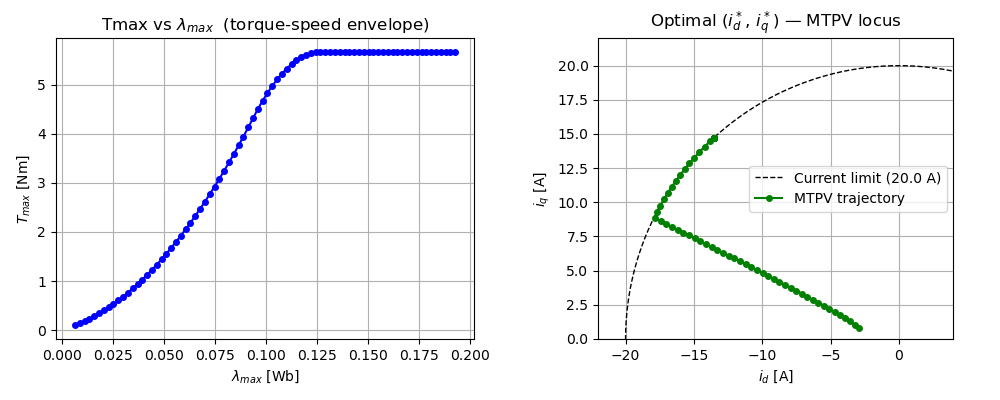

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# --- Plot 1: Torque capability vs flux budget ---
# As lam_max shrinks (higher rpm), achievable torque drops → FW torque-speed curve.
axes[0].plot(lam_max_grid, Tmax_LUT, 'b-o', markersize=4)
axes[0].set_xlabel(r"$\lambda_{max}$ [Wb]")
axes[0].set_ylabel(r"$T_{max}$ [Nm]")
axes[0].set_title("Tmax vs $\\lambda_{max}$  (torque-speed envelope)")
axes[0].grid(True)

# --- Plot 2: MTPV trajectory on id-iq plane ---
# Green curve: optimal (id*, iq*) locus as flux limit tightens (higher speed).
# At large lam_max (low speed), trajectory sits on the current-limit circle (MTPA region).
# As lam_max shrinks, the operating point moves into the FW interior (MTPV region).
theta = np.linspace(0, np.pi, 200)
axes[1].plot(p_["Imax"] * np.cos(theta), p_["Imax"] * np.sin(theta),
             'k--', linewidth=1, label=f"Current limit ({p_['Imax']} A)")
axes[1].plot(Id_at_Tmax, Iq_at_Tmax, 'g-o', markersize=4, label="MTPV trajectory")
axes[1].set_xlabel(r"$i_d$ [A]")
axes[1].set_ylabel(r"$i_q$ [A]")
axes[1].set_title(r"Optimal $(i_d^*,\, i_q^*)$ — MTPV locus")
axes[1].legend()
axes[1].grid(True)
axes[1].set_xlim(-p_["Imax"] * 1.1, p_["Imax"] * 0.2)
axes[1].set_ylim(0, p_["Imax"] * 1.1)
axes[1].set_aspect('equal')

plt.tight_layout()
plt.show()


In [50]:
# =========================
# Part II: given (Tref, lam_ref) -> (id*, iq*) that minimizes current magnitude
# minimize id^2 + iq^2
# s.t. Te = Tref, |lambda| <= lam_ref, id^2+iq^2 <= Imax^2, id<=0, iq>=0
# =========================
def solve_min_current_for_T_lam(Tref, lam_ref, p_, x0=None):
    Imax = p_["Imax"]
    bounds = [(-Imax, 0.0), (0.0, Imax)]  # id <= 0 (demagnetizing), iq >= 0 (torque-producing)

    def cost(x):
        # Objective: minimize squared current magnitude |I|^2 = id^2 + iq^2
        # This is the MTPA (Maximum Torque Per Ampere) criterion
        return x[0] ** 2 + x[1] ** 2

    cons = [
        # (C1) Torque equality: must exactly hit the reference torque Tref [Nm]
        {"type": "eq", "fun": lambda x: Te(x[0], x[1], p_) - Tref},
        # (C2) Flux inequality: |lambda(id,iq)| must stay within the voltage-derived flux limit
        #      lam_ref = Vmax / omega_e  (from Part I), enforces the field-weakening boundary
        {"type": "ineq", "fun": lambda x: lam_ref - lam_mag(x[0], x[1], p_)},
        # (C3) Current limit: |I|^2 = id^2 + iq^2 must not exceed Imax^2
        {"type": "ineq", "fun": lambda x: Imax**2 - (x[0] ** 2 + x[1] ** 2)},
    ]

    inits = []
    if x0 is not None:
        # Warm start: use the user-supplied initial guess (e.g., from Part III LUT)
        inits.append(np.array(x0, dtype=float))

    # Rough initial guess using only magnet torque: Te ≈ 1.5 * p_ * psi_f * iq  (id = 0)
    # => iq0 ≈ Tref / (1.5 * pole_pairs * psi_f)
    denom = 1.5 * p_["pole_pairs"] * max(p_["psi_f"], 1e-9)
    iq0 = Tref / denom
    if 0.0 <= iq0 <= Imax:
        inits.append(np.array([0.0, iq0]))

    # Additional field-weakening-style initial guesses distributed along the current-limit circle
    # id_guess = -sqrt(Imax^2 - iq_guess^2) places the point on the circle boundary
    for frac in [0.2, 0.5, 0.8, 1.0]:
        iq_guess = frac * Imax
        id_guess = -np.sqrt(max(Imax**2 - iq_guess**2, 0.0))
        inits.append(np.array([id_guess, iq_guess]))
    inits.append(np.array([-0.2 * Imax, 0.2 * Imax]))  # Light field-weakening guess

    best_cost = np.inf
    best_x = None
    best_res = None

    for x0_try in inits:
        res = minimize(
            cost,
            x0_try,
            method="SLSQP",       # Sequential Least SQuares Programming — handles nonlinear constraints
            bounds=bounds,
            constraints=cons,
            options={"maxiter": 1200, "ftol": 1e-12, "disp": False},
        )
        if not res.success:
            continue  # Skip failed solves; try the next initial guess

        id_, iq = res.x
        # Post-check: reject solutions that violate constraints beyond numerical tolerance
        if abs(Te(id_, iq, p_) - Tref) > 1e-3:
            continue  # Torque error too large
        if lam_mag(id_, iq, p_) > lam_ref + 1e-6:
            continue  # Flux limit violated
        if (id_**2 + iq**2) > Imax**2 + 1e-6:
            continue  # Current limit violated

        c = cost(res.x)
        if c < best_cost:
            # Keep the best (minimum-current) feasible solution across all initial guesses
            best_cost = c
            best_x = res.x.copy()
            best_res = res

    return best_x, best_res


In [51]:
# =========================
# 2D LUT Build: (lam_max, T_ratio) → (id*, iq*)
# Axes:
#   lam_max  : flux limit [Wb], derived from motor operating range
#              lam_lower = Vmax / omega_e_max  (highest speed, tightest voltage budget)
#              lam_upper = |lambda| at max current, low speed (no voltage constraint)
#   T_ratio  : normalized torque = Tref / Tmax(lam_max)  in [0, 1)
# =========================
N_lam   = 20   # number of flux-axis grid points
N_tref  = 10   # number of torque-ratio grid points

# Reuse the motor-parameter-derived bounds (already computed in the notebook)
# lam_lower ~ 0.006 Wb at rpm_max=6000, lam_upper ~ 0.19 Wb at low speed + Imax
lam_grid    = np.linspace(lam_lower, lam_upper, N_lam)
Tratio_grid = np.linspace(0.0, 0.999, N_tref)  # 0% to ~100% of Tmax

# --- Step 1: Build Part III LUT (Tmax sweep over lam_max) ---
# This gives us Tmax(lam_max) and the corresponding (id*, iq*) MTPV trajectory,
# which we reuse as warm-start guesses for Part II.
lam_max_grid = lam_grid
Tmax_LUT, Id_at_Tmax, Iq_at_Tmax = build_part3_LUT(lam_max_grid, p_)

# --- Step 2: Allocate 2D LUT arrays ---
Id_LUT_2D = np.full((N_lam, N_tref), np.nan)
Iq_LUT_2D = np.full((N_lam, N_tref), np.nan)

print("Building 2D LUT (lam_max × T_ratio) ...")
for i, lam_max in enumerate(lam_grid):
    # Maximum achievable torque at this flux limit (from Part III)
    Tmax_i = float(np.interp(lam_max, lam_max_grid, Tmax_LUT))

    # Warm-start: use Part III MTPV point as initial guess for Part II solver
    id0_w = float(np.interp(lam_max, lam_max_grid, Id_at_Tmax))
    iq0_w = float(np.interp(lam_max, lam_max_grid, Iq_at_Tmax))

    for j, ratio in enumerate(Tratio_grid):
        Tref_ij = ratio * Tmax_i

        # Skip near-zero torque: set (id, iq) = (0, 0) to avoid solver instability
        if ratio < 0.01:
            Id_LUT_2D[i, j] = 0.0
            Iq_LUT_2D[i, j] = 0.0
            continue

        # Part II: find minimum-current (id*, iq*) for this (lam_max, Tref)
        sol_ij, _ = solve_min_current_for_T_lam(
            Tref_ij, lam_max, p_, x0=[id0_w, iq0_w]
        )
        if sol_ij is not None:
            Id_LUT_2D[i, j] = sol_ij[0]
            Iq_LUT_2D[i, j] = sol_ij[1]
        # else: leave as NaN — infeasible or solver failed at this grid point

# --- Step 3: Build 2D interpolators for runtime lookup ---
# Runtime: given (lam_ref, Tref/Tmax), return (id*, iq*) via bilinear interpolation
interp_id = RegularGridInterpolator(
    (lam_grid, Tratio_grid), Id_LUT_2D,
    method='linear', bounds_error=False, fill_value=None
)
interp_iq = RegularGridInterpolator(
    (lam_grid, Tratio_grid), Iq_LUT_2D,
    method='linear', bounds_error=False, fill_value=None
)

print("Done! 2D LUT ready.")
print(f"  lam axis : {lam_grid[0]:.4f} ~ {lam_grid[-1]:.4f} Wb  ({N_lam} pts)")
print(f"  T_ratio  : {Tratio_grid[0]:.3f} ~ {Tratio_grid[-1]:.3f}      ({N_tref} pts)")
nan_frac = np.isnan(Id_LUT_2D).mean() * 100
print(f"  NaN fraction: {nan_frac:.1f}%  (infeasible grid points)")


Building Part III LUT: Tmax(lambda_max) ...
Done.
Building 2D LUT (lam_max × T_ratio) ...
Done! 2D LUT ready.
  lam axis : 0.0064 ~ 0.1928 Wb  (20 pts)
  T_ratio  : 0.000 ~ 0.999      (10 pts)
  NaN fraction: 0.0%  (infeasible grid points)


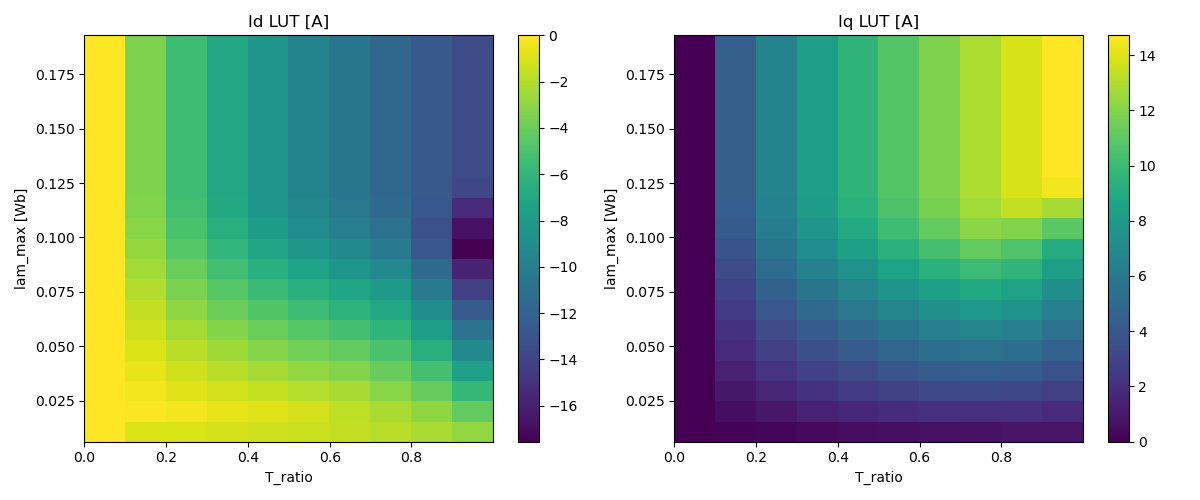

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

im0 = axes[0].imshow(Id_LUT_2D, aspect='auto', origin='lower',
                      extent=[Tratio_grid[0], Tratio_grid[-1], lam_grid[0], lam_grid[-1]])
axes[0].set_title("Id LUT [A]"); axes[0].set_xlabel("T_ratio"); axes[0].set_ylabel("lam_max [Wb]")
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(Iq_LUT_2D, aspect='auto', origin='lower',
                      extent=[Tratio_grid[0], Tratio_grid[-1], lam_grid[0], lam_grid[-1]])
axes[1].set_title("Iq LUT [A]"); axes[1].set_xlabel("T_ratio"); axes[1].set_ylabel("lam_max [Wb]")
plt.colorbar(im1, ax=axes[1])

plt.tight_layout()
plt.show()


In [ ]:
%matplotlib widget
from matplotlib.widgets import Slider

# Background grid for current, flux, and torque contours
id_vec_bg = np.linspace(-p_["Imax"] * 1.1, p_["Imax"] * 0.1, 100)
iq_vec_bg = np.linspace(0, p_["Imax"] * 1.1, 100)
ID_bg, IQ_bg = np.meshgrid(id_vec_bg, iq_vec_bg)

# Current magnitude grid
I_bg = np.sqrt(ID_bg**2 + IQ_bg**2)

# Flux magnitude grid
LAM_d_bg = p_["psi_f"] + p_["Ld"] * ID_bg
LAM_q_bg = p_["Lq"] * IQ_bg
LAM_bg = np.sqrt(LAM_d_bg**2 + LAM_q_bg**2)

# Torque magnitude grid
TE_bg = 1.5 * p_["pole_pairs"] * (p_["psi_f"] * IQ_bg + (p_["Ld"] - p_["Lq"]) * ID_bg * IQ_bg)


# ===== MTPA trajectory (closed-form solution) =====
# MTPA: find id that minimizes |I|^2 = id^2 + iq^2 subject to fixed torque
# Closed-form: id = (k - sqrt(k^2 + 8*I^2)) / 4,  where k = psi_f / (Lq - Ld)
delta = p_["Lq"] - p_["Ld"]   # saliency; > 0 for IPMSM
I_sweep = np.linspace(0.0, p_["Imax"], 50)

if abs(delta) < 1e-12:
    # Non-salient (SPMSM): MTPA collapses to id = 0
    id_mtpa, iq_mtpa = np.zeros_like(I_sweep), I_sweep.copy()
else:
    k = p_["psi_f"] / delta
    id_mtpa = (k - np.sqrt(k**2 + 8.0 * I_sweep**2)) / 4.0
    iq_mtpa = np.sqrt(np.maximum(I_sweep**2 - id_mtpa**2, 0.0))

# Valid mask: finite values, motoring quadrant (id <= 0, iq >= 0)
v_mtpa = np.isfinite(id_mtpa) & np.isfinite(iq_mtpa) & (id_mtpa <= 1e-9) & (iq_mtpa >= -1e-9)

plt.close('all')

fig, ax = plt.subplots(figsize=(8, 6))
plt.subplots_adjust(bottom=0.28)

# Slider axes
ax_rpm  = plt.axes([0.25, 0.1, 0.50, 0.02])
ax_tref = plt.axes([0.25, 0.05, 0.50, 0.02])
s_rpm  = Slider(ax_rpm,  'rpm',   100, 6000, valinit=3000, valstep=50,  initcolor='none')
s_tref = Slider(ax_tref, 'Tref',  0,   52,   valinit=2,    valstep=0.5, initcolor='none')

# ===== Static elements: drawn once, never change =====
ax.contourf(ID_bg, IQ_bg, I_bg, levels=[0, p_["Imax"]], colors=['#AED6F1'], alpha=0.3)
ax.contour( ID_bg, IQ_bg, I_bg, levels=[p_["Imax"]],    colors=['#2E86C1'], linewidths=1.5)
line_mtpa, = ax.plot(id_mtpa[v_mtpa], iq_mtpa[v_mtpa], 'orange', lw=1.8, label="MTPA")
line_traj, = ax.plot(Id_at_Tmax, Iq_at_Tmax, 'purple', lw=1.8, label="Optimal traj.")

# Operating point marker — label updated dynamically in redraw()
point_op, = ax.plot([], [], 'ro', ms=12, mec='darkred', mew=2, label='OP')

ax.set_xlabel(r"$i_d$ [A]")
ax.set_ylabel(r"$i_q$ [A]")
ax.set_xlim(id_vec_bg[0], id_vec_bg[-1])
ax.set_ylim(0, iq_vec_bg[-1])
ax.set_aspect('equal')   # ← 추가: d-q 스케일 동일
ax.grid(True, alpha=0.3)

# ===== Dynamic artists: replaced on every slider update =====
dyn_artists = []   # holds ContourSet objects to be removed each frame

def _update_legend():
    """Rebuild legend, filtering out artists with auto-generated underscore labels."""
    handles = [line_mtpa, line_traj, point_op]
    ax.legend(loc="upper right", fontsize=8,
              handles=[h for h in handles if not h.get_label().startswith('_')])

_update_legend()

def redraw(val):

    # --- Compute operating conditions ---
    rpm      = s_rpm.val
    Tref_cmd = s_tref.val
    lam_ref  = part1_lambda_max_ff(rpm, Vdc, p_)
    Tmax_at_lam = float(np.interp(lam_ref, lam_max_grid, Tmax_LUT))
    Tref     = float(np.clip(Tref_cmd, 0.0, Tmax_at_lam * 0.999))
    T_ratio  = Tref / max(Tmax_at_lam, 1e-6)

    # LUT lookup: (lam_ref, T_ratio) → (id*, iq*)
    pt    = np.array([[lam_ref, T_ratio]])
    id_op = interp_id(pt).item()
    iq_op = interp_iq(pt).item()

    # --- Remove previous dynamic artists ---
    for a in dyn_artists:
        try:
            a.remove()
        except Exception:
            pass
    dyn_artists.clear()

    # --- Flux limit region (changes with rpm) ---
    cf = ax.contourf(ID_bg, IQ_bg, LAM_bg, levels=[0, lam_ref], colors=['#A9DFBF'], alpha=0.4)
    ct = ax.contour( ID_bg, IQ_bg, LAM_bg, levels=[lam_ref],    colors=['#1E8449'], linewidths=1.5)
    dyn_artists.extend([cf, ct])

    # --- Torque contours (dashed = commanded, solid = achieved after clipping) ---
    if Tref_cmd > 0:
        c1 = ax.contour(ID_bg, IQ_bg, TE_bg, levels=[Tref_cmd],
                        colors=['red'], linewidths=1.5, linestyles='--')
        dyn_artists.append(c1)
    if Tref > 0:
        c2 = ax.contour(ID_bg, IQ_bg, TE_bg, levels=[Tref],
                        colors=['red'], linewidths=2.5)
        dyn_artists.append(c2)

    # --- Update operating point marker ---
    point_op.set_data([id_op], [iq_op])
    point_op.set_label("OP")

    ax.set_title(
        f"$i_d^*$ = $\\bf{{{id_op:.1f}}}$ A,  $i_q^*$ = $\\bf{{{iq_op:.1f}}}$ A"
        f"    |    $T_{{ref}}$ = $\\bf{{{Tref:.1f}}}$ / {Tmax_at_lam:.1f} Nm",
        fontsize=12
    )
    _update_legend()
    fig.canvas.draw_idle()

s_rpm.on_changed(redraw)
s_tref.on_changed(redraw)
redraw(None)
plt.show()


KeyError: 'p_'